# Projeto Fundamentos de Aprendizagem Automática

**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

## Problema
**Prever a nota final** com base em todas as variáveis comportamentais, exceto 


* student_id
* productivity_score  
* burnout_level 
* focus_index
    

## Variáveis-Alvo (Targets)

### Cenário de Regressão (y)

Prever **Exam Score** (nota de exame). 

## Stakeholders

- **Os próprios estudantes** :Beneficiariam ao compreender de forma clara como os seus hábitos de vida (como as horas de sono, tempo de ecrã e o balanço entre estudo e lazer) impactam diretamente o seu desempenho académico. Ter acesso a esta previsão permite-lhes ajustar comportamentos de forma proativa e atempada, evitando o insucesso escolar (chumbo) ou níveis extremos de exaustão (burnout).
    
- **A instituição de ensino / Escola** :Pode utilizar este modelo preditivo para identificar antecipadamente uma percentagem de alunos em risco de reprovação. Isto permite à gestão escolar uma melhor alocação de recursos pedagógicos, como a promoção de turmas de apoio extra ou a reavaliação da carga de trabalhos exigida.
    
- **Conselheiros / Tutores** :Passam a ter acesso a uma ferramenta de apoio à decisão baseada em dados reais para oferecer um acompanhamento muito mais personalizado. Em vez de conselhos genéricos, o tutor pode focar-se nas variáveis específicas que o modelo identificou como problemáticas para um determinado aluno (por exemplo, excesso de horas em videojogos ou falta de qualidade de sono).
    
- **Serviços de Apoio ao Estudante(Apoio Psicológico)** :Podem atuar de forma preventiva junto de alunos cujo perfil cruze um baixo rendimento académico com indicadores de má saúde mental (como altos níveis de ingestão de cafeína e privação de sono). O modelo serve como um sistema de alerta para oferecer suporte psicológico antes que o aluno atinja um ponto de rutura.


### Ler ficheiro obter feature Variables e Target Variables e tratar dados missing

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder


# ler ficherio de student_records com missing values
df_student_records = pd.read_csv('student_records_missing.csv')
df_colunas = df_student_records.columns


# imprimir percentagem missing values por coluna
missing_percent = df_student_records.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])


# Definir Variável y
y = df_student_records["exam_score"].copy()  # Variável y com a coluna "exam_score"




# Definir Variável X
df_student_records.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
X = df_student_records.copy()  # Variável X com as colunas restantes

# print(X.head())





# one split para separar os dados em treino e teste
X_learning, X_test, y_learning, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)




# Separar colunas numéricas e categóricas em X_learning para preencher os valores vazios
num_cols = X_learning.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_learning.select_dtypes(include=['object', 'string']).columns.tolist()



# Calcular a mediana para as colunas numéricas e a moda para as colunas categóricas em X_learning
medians = X_learning[num_cols].median()
modes = X_learning[cat_cols].mode().iloc[0]



# Preencher os valores vazios em X_learning com as medianas e modas calculadas
X_learning[num_cols] = X_learning[num_cols].fillna(medians)
X_learning[cat_cols] = X_learning[cat_cols].fillna(modes)

# Preencher os valores vazios em X_test com as mesmas medianas e modas calculadas a partir de X_learning
X_test[num_cols] = X_test[num_cols].fillna(medians)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)







print("\n Total atual de valores vazios :", X_learning.isnull().sum().sum() + X_test.isnull().sum().sum())
# print(X_learning.head())
# print(X_test.head())


#Utilizando(One-Hot Encoding) para transformar as colunas categóricas em variáveis dummy
X_learning = pd.get_dummies(X_learning, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
# print(X_learning.head())







--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64

 Total atual de valores vazios : 0


### Árvore de Decisão
#### 1. Utilizando GridSearchCV e Crosvalidation encontrar best parametro

In [2]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



param_grid = {
"criterion": ["squared_error", "absolute_error"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=7), # Utilizar árvore de regressão
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error", # Objetivo de otimização: minimizar o RMSE
    cv=KFold(n_splits=5, shuffle=True, random_state=7), # Utilizar KFold simples
    n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar no conjunto de aprendizagem

print("Best parameters:", grid.best_params_)
# O GridSearch do sklearn converte o erro em negativo, por isso é necessário negar ao extrair
print("Best mean CV RMSE:", round(-grid.best_score_, 3))

# Avaliação final no conjunto de teste
final_model = grid.best_estimator_
y_test_pred = final_model.predict(X_test)

# Calcular as métricas de avaliação específicas para regressão
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n--- Métricas no Conjunto de Teste (Test Set Metrics) ---")
print(f"RMSE (Root Mean Squared Error): {round(rmse, 3)}")
print(f"MAE (Mean Absolute Error): {round(mae, 3)}")
print(f"R2 Score: {round(r2, 3)}")



Best parameters: {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best mean CV RMSE: 8.386

--- Métricas no Conjunto de Teste (Test Set Metrics) ---
RMSE (Root Mean Squared Error): 8.159
MAE (Mean Absolute Error): 6.419
R2 Score: 0.553


### Decision tree grafico

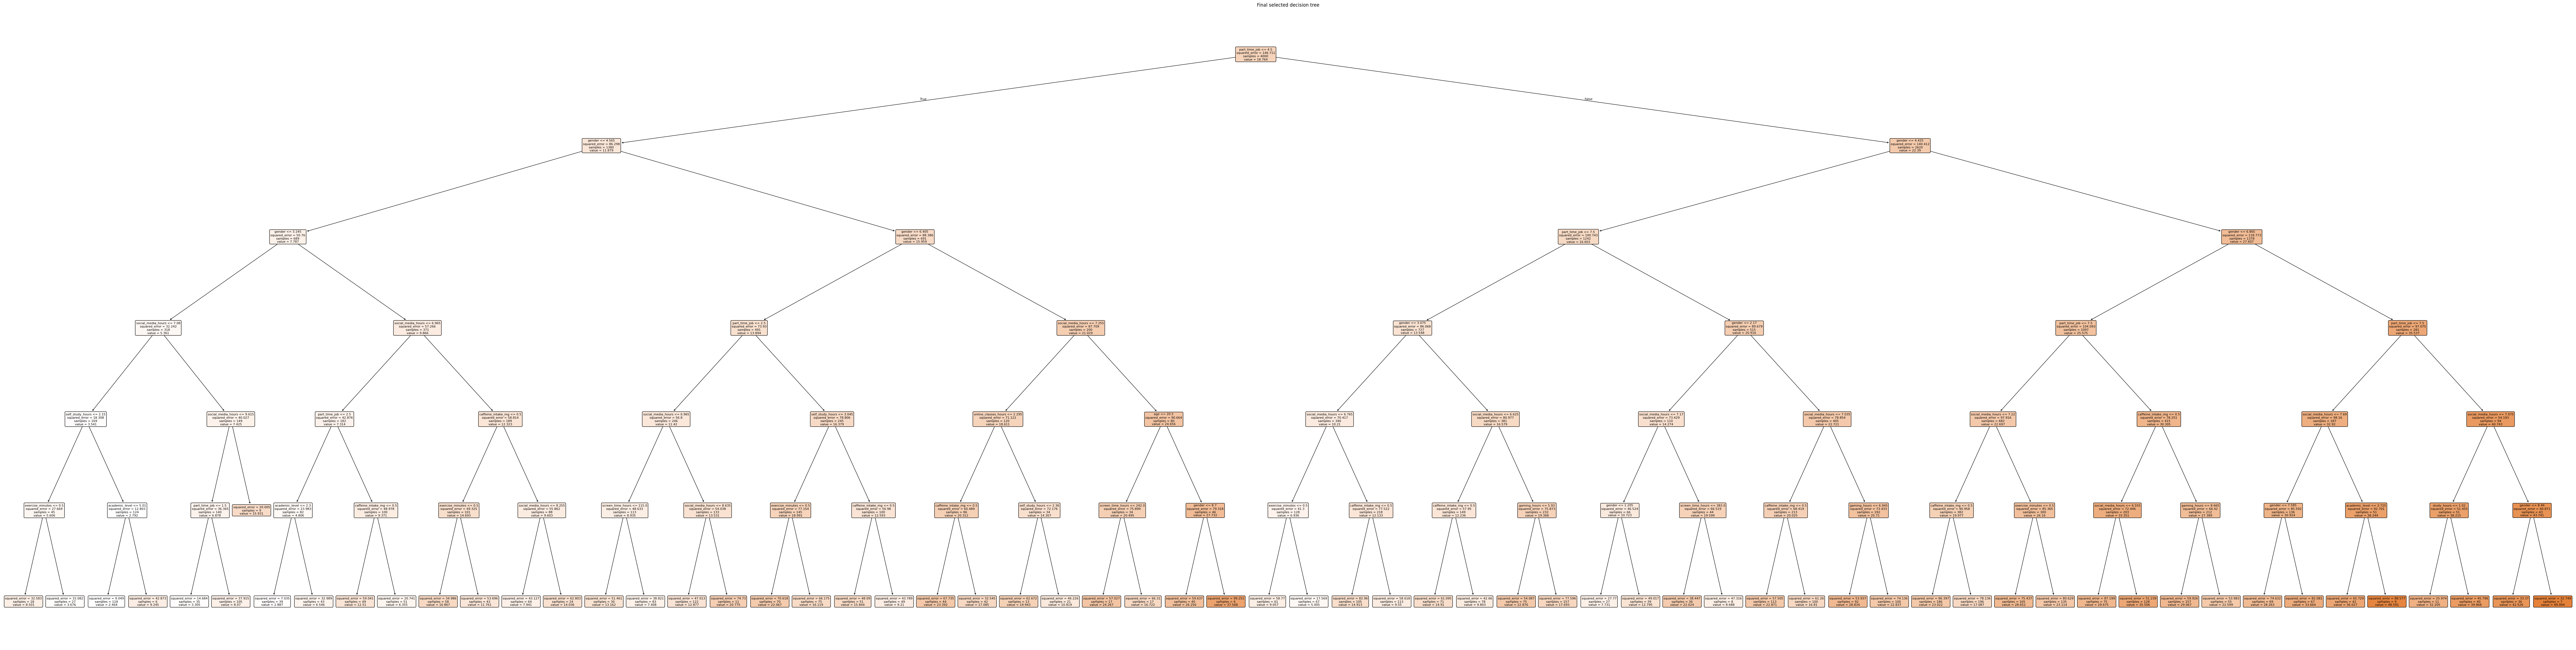

In [3]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(120, 30))
plot_tree(
final_model,
feature_names=X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,
)

plt.title("Final selected decision tree")
plt.show()

### Regresao linear

-> Cross-Validation: 交叉验证的平均 RMSE 是: 6.835

The score is:  0.6847989311475485
The alpha is:  18.76765029022117
The other parameters are: 
	 B1 ->    -0.032
	 B2 ->     6.412
	 B3 ->     0.944
	 B4 ->    -0.045
	 B5 ->    -1.256
	 B6 ->    -0.658
	 B7 ->     2.958
	 B8 ->    -1.503
	 B9 ->     0.477
	 B10 ->    -0.826
	 B11 ->    -1.766
	 B12 ->    -2.481
	 B13 ->     6.181
	 B14 ->     0.072
	 B15 ->    -0.087
	 B16 ->     0.015
	 B17 ->    -0.135
	 B18 ->     0.107
	 B19 ->     0.029
	 B20 ->     0.033
	 B21 ->    -0.080
	 B22 ->     0.047
The rmse is:  6.652221022240441
The Mean Absolute Error is:  5.292652406428378
The Coefficient of Determination is:  0.7025335788568188
The Pearson Correlation Score is: 0.8383 (p-value=3.405817e-265)

The Maximum Error is:  24.693561022318317


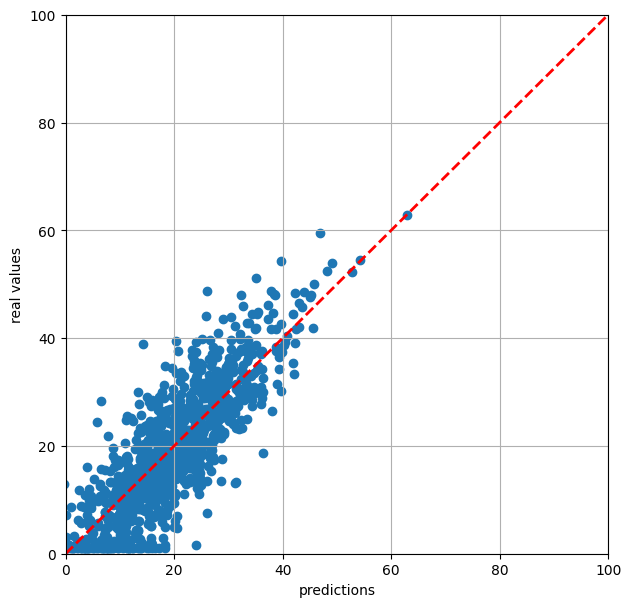

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, max_error
from scipy.stats import pearsonr



# Vamos usar StandardScaler com cordo formulario: z = (x - u) / s
scaler = StandardScaler()

# Para não modificar a tabela original, criamos uma cópia para o conjunto de treino e de teste
X_learning_rl = X_learning.copy()
X_test_rl = X_test.copy()



X_learning_rl[num_cols] = scaler.fit_transform(X_learning_rl[num_cols])
X_test_rl[num_cols] = scaler.transform(X_test_rl[num_cols])




reg = LinearRegression()
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = cross_val_score(reg, X_learning_rl, y_learning, cv=cv_strategy, scoring='neg_root_mean_squared_error')
print("-> Cross-Validation: 交叉验证的平均 RMSE 是: {:.3f}\n".format(-cv_scores.mean()))




reg.fit(X_learning_rl, y_learning)
print("The score is: ", reg.score(X_learning_rl, y_learning))
print("The alpha is: ", reg.intercept_)
print("The other parameters are: ")
for i, beta in enumerate(reg.coef_):
    print("\t B%d -> %9.3f"% (i+1, beta))





def printRegStatistics(truth, preds):
    print("The rmse is: ", root_mean_squared_error(truth, preds)) #Quanto menor o valor, melhor o desempenho do modelo
    print("The Mean Absolute Error is: ", mean_absolute_error(truth, preds))#Quanto menor o valor, melhor o desempenho do modelo
    print("The Coefficient of Determination is: ", r2_score(truth, preds))#Quanto maior o valor (próximo de 1), melhor o desempenho do modelo
    corr, pval = pearsonr(truth, preds)
    print("The Pearson Correlation Score is: %6.4f (p-value=%e)\n"%(corr,pval))
    print("The Maximum Error is: ", max_error(truth, preds))


preds=reg.predict(X_test_rl)
printRegStatistics(y_test, preds)
plt.figure(figsize=(7,7))
plt.scatter(preds, y_test)
plt.grid()
plt.plot([0, 100], [0, 100], c="r", linestyle='--', linewidth=2)

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("predictions")
plt.ylabel("real values")
plt.show()



